In [115]:
from profis.utils.modelinit import initialize_model
import pandas as pd
from profis.utils.finger import encode
import torch

In [116]:
krfp = True
device = torch.device('cuda')
if krfp:
    CONFIG_PATH = 'models/SMILES_ECFP/hyperparameters.ini'
    TEST_DATA_PATH = 'data/RNN_dataset_ECFP_val_10.parquet'
else:
    CONFIG_PATH = 'models/best_ECFP_DeepSMILES/hyperparameters.ini'
    TEST_DATA_PATH = 'data/RNN_dataset_ECFP_val_10.parquet'

VAE = initialize_model(CONFIG_PATH, device)
if krfp:
    VAE.load_state_dict(torch.load('models/SMILES_ECFP/epoch_300.pt'))
else:
    VAE.load_state_dict(torch.load('models/best_ECFP_SMILES/epoch_300.pt'))

In [117]:
df = pd.read_parquet(TEST_DATA_PATH).sample(10000)

In [118]:
mus, _ = encode(df, VAE, device)

In [119]:
encoded_df = pd.DataFrame(mus)

In [120]:
encoded_df

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,-0.641262,-1.342686,0.519632,-0.843109,-0.532568,0.949846,1.916296,1.350388,1.965895,0.554590,...,0.555447,-1.108394,-0.468406,-0.195958,-1.034950,-1.784767,0.341220,-0.381913,0.542818,0.747408
1,0.128682,-2.961386,0.298262,-0.389937,0.778173,-0.428963,-2.254966,0.595066,0.987535,-0.828171,...,-0.991397,1.137849,-0.078064,0.335955,-1.349635,-0.821068,0.726223,1.512944,0.132816,-0.236209
2,2.232864,1.432874,1.142208,0.332448,-0.792027,0.980689,0.105848,-0.347487,0.033364,2.503512,...,1.692816,0.616374,-0.172963,-0.134706,-1.215068,2.900786,-0.706334,0.187503,1.583863,-1.362166
3,-1.435722,0.854185,1.642299,1.643089,0.899320,0.484328,0.315951,0.397901,1.643005,0.361405,...,0.293676,-0.202470,1.202329,-2.099606,-0.432344,-0.544401,-2.422685,-1.205827,0.913750,-1.497731
4,-0.720379,0.898062,-0.048674,0.803228,-0.505069,1.011402,-0.230376,1.912674,-0.738028,-0.018536,...,0.668262,-1.260536,0.446773,-0.242720,-2.923829,-0.642574,0.589400,-1.945158,0.746597,1.055031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.479487,0.634518,-0.064538,-0.252129,0.593621,0.134823,0.575675,1.086093,1.020536,1.651885,...,-0.310893,0.283368,0.009512,1.806010,-0.284722,-0.651257,-0.386122,-0.171454,1.627852,-0.323041
9996,-0.301126,-0.680757,-0.681348,-0.717620,0.104153,0.848908,-0.793343,1.163921,0.561365,-0.798680,...,-1.166271,-0.273409,-0.781540,-0.525496,-0.376935,-0.404266,-0.945558,0.295234,1.777657,-0.117128
9997,-0.123319,-0.909306,2.209715,-0.706417,1.005348,0.245634,-0.650942,-0.725915,0.389991,-1.372324,...,0.792506,0.413977,-1.712646,0.969412,-1.082838,-0.987541,1.164878,0.630498,0.265642,-0.448908
9998,-0.189648,0.782827,-2.146766,-0.125056,-0.140029,0.131655,0.004020,-0.868330,0.694953,-1.688985,...,-0.741144,-0.725231,0.357123,-0.466470,0.116838,-0.894889,-0.087887,-0.122086,1.589766,0.599234


In [106]:
encoded_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,-0.276312,-0.080334,0.218274,-0.048252,-0.057467,-0.205241,-0.005214,-0.092668,-0.068733,0.038462,...,0.001068,-0.037469,0.056261,-0.038159,0.064326,0.100416,-0.049405,-0.204948,0.064341,0.250895
std,1.059807,0.970790,1.140619,0.966715,0.958880,1.016408,0.939577,1.037472,0.968848,0.975390,...,0.970482,0.954718,1.071233,0.960323,0.949084,0.959750,1.081215,1.022236,1.024697,1.041361
min,-4.068356,-3.691841,-3.159155,-3.810580,-3.628609,-3.351097,-3.485028,-4.118832,-4.031595,-3.602923,...,-3.835788,-3.672856,-4.261328,-3.314899,-4.399408,-3.505356,-4.334957,-4.088875,-3.722400,-3.564040
25%,-1.011485,-0.726174,-0.502944,-0.671696,-0.695158,-0.916567,-0.628567,-0.772621,-0.724300,-0.613897,...,-0.646585,-0.664409,-0.651063,-0.687443,-0.540169,-0.540260,-0.741056,-0.890995,-0.630593,-0.452731
50%,-0.337722,-0.071356,0.226793,-0.009211,-0.073730,-0.241716,0.017176,-0.077947,-0.058917,0.038849,...,-0.000851,-0.040172,0.095156,-0.052875,0.073259,0.023765,-0.055593,-0.205959,0.075451,0.289203
75%,0.403607,0.583534,1.003726,0.605967,0.594712,0.458926,0.635232,0.614384,0.584259,0.703036,...,0.637824,0.579495,0.775075,0.607507,0.716307,0.681069,0.636189,0.492886,0.763022,0.985322
max,4.436142,3.669073,3.875967,3.899714,3.628350,3.874776,3.508854,3.912800,3.828610,3.780020,...,3.753076,3.620634,3.899887,3.528369,3.617270,4.941262,3.970742,3.526766,3.862649,3.841100


/home/hubert/miniconda3/envs/profis/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/hubert/miniconda3/envs/profis/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/hubert/miniconda3/envs/profis/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/hubert/miniconda3/envs/profis/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a 

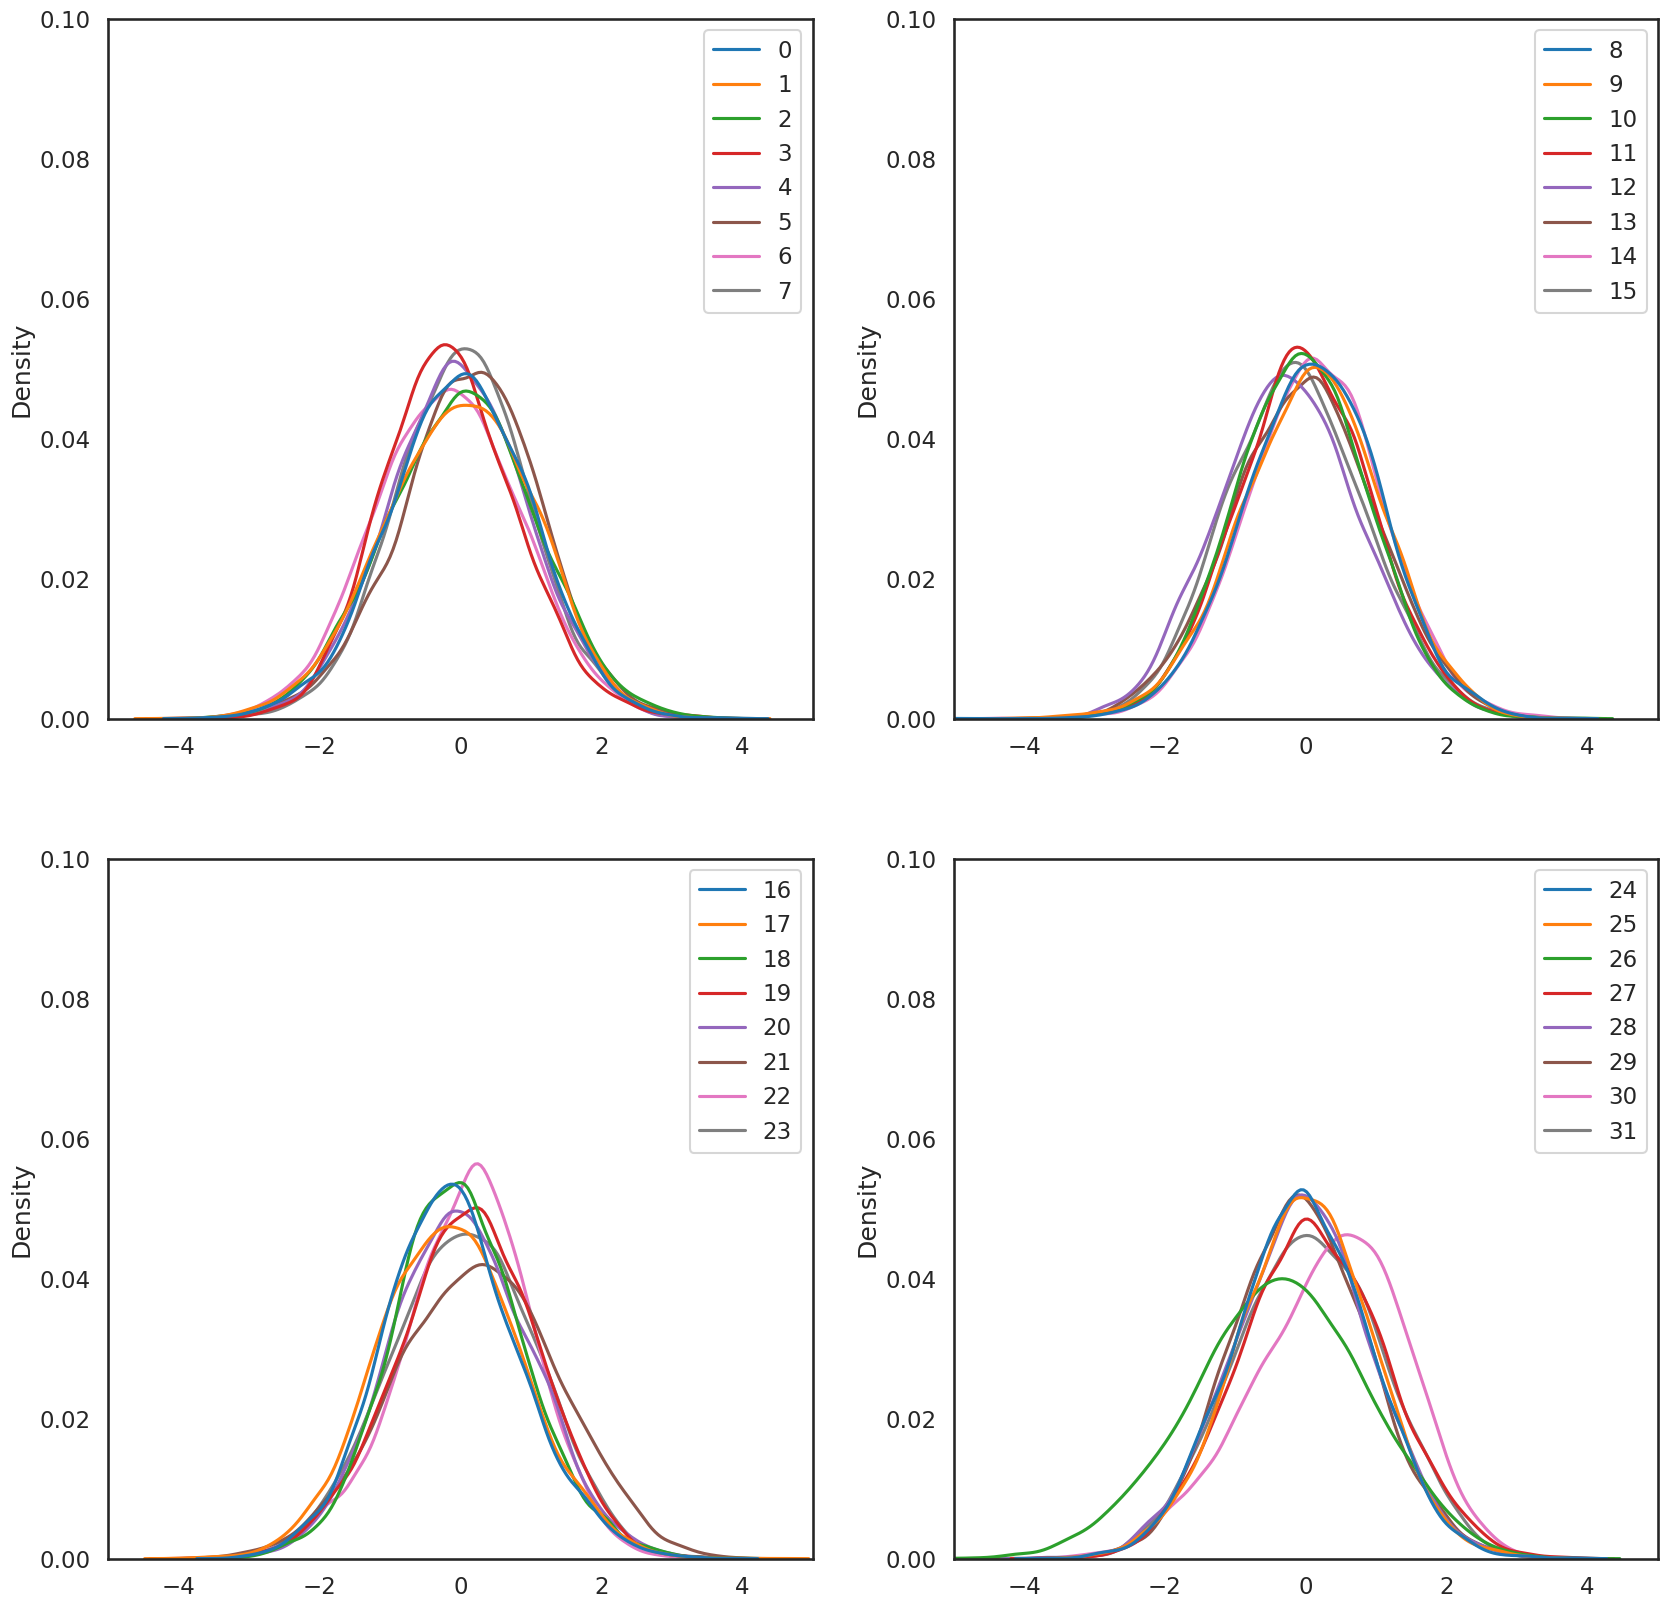

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('white')
sns.set_context('talk')

batch1 = encoded_df.columns[:8]
batch2 = encoded_df.columns[8:16]
batch3 = encoded_df.columns[16:24]
batch4 = encoded_df.columns[24:32]

fig, axs = plt.subplots(2, 2, figsize=(20, 20))
ax1 = sns.kdeplot(data=encoded_df[batch1], ax=axs[0, 0])
ax1.set_xlim(-5, 5)
ax1.set_ylim(0, 0.1)
ax2 = sns.kdeplot(data=encoded_df[batch2], ax=axs[0, 1])
ax2.set_xlim(-5, 5)
ax2.set_ylim(0, 0.1)
ax3 = sns.kdeplot(data=encoded_df[batch3], ax=axs[1, 0])
ax3.set_xlim(-5, 5)
ax3.set_ylim(0, 0.1)
ax4 = sns.kdeplot(data=encoded_df[batch4], ax=axs[1, 1])
ax4.set_xlim(-5, 5)
ax4.set_ylim(0, 0.1)

plt.savefig('old_ECFP_distributions.png')

In [ ]:
from profis.utils.vectorizer import SMILESVectorizer
from profis.gen.dataset import SMILESDataset
from torch.utils.data import DataLoader

vectorizer = SMILESVectorizer(pad_to_len=128)

dataset = SMILESDataset(df, vectorizer)
dataloader = DataLoader(dataset, batch_size=1024, shuffle=False)

reconstructions = []
with torch.no_grad():
    for i, batch in enumerate(dataloader):
        print(f'Batch {i+1}/{len(dataloader)}')
        X, y = batch
        X = X.to(device)
        y_hat, _ = VAE(X, y)
        reconstructions.append(y_hat.detach().cpu().numpy())
len(reconstructions)

Batch 1/110
Batch 2/110
Batch 3/110
Batch 4/110
Batch 5/110
Batch 6/110
Batch 7/110


In [65]:
from profis.pred.pred import stochastic_decoder
import numpy as np
n_trials = 1000

reconstructions = np.concatenate(reconstructions)
for vector in reconstructions:
    print(stochastic_decoder(vector, vectorizer, n_trials=n_trials))
    

df["smiles"] = [
                stochastic_decoder(vector, vectorizer, n_trials=n_trials)
                for vector in reconstructions
            ]

NameError: name 'reconstructions' is not defined

In [72]:
import pandas as pd
df = pd.read_parquet('data/RNN_dataset_ECFP_val_10.parquet').sample(150)['smiles']
df.head()

index
531734                            O=c1nc(NO)ccn1C1CCC(CO)O1
760804    CCN(CC)CCC(=O)Nc1ccc(O)c2c1C(=O)c1c(O)ccc(O)c1...
128677                  CC(C)Cc1ccc(C(C)C(=O)OCc2ccccc2)cc1
639292    O=C(O)c1cn(-c2c(F)c(F)c(F)c(F)c2F)c2c(F)c(F)c(...
698364                        CC(C)c1nc2cc(Cl)c(Cl)cc2[nH]1
Name: smiles, dtype: object

In [73]:
from rdkit import Chem
from rdkit.Chem.rdMolDescriptors import CalcTPSA, CalcExactMolWt, CalcNumHBA, CalcNumHBD, CalcFractionCSP3
from rdkit.Chem.Crippen import MolLogP

df1 = pd.read_csv('results/predictions_filtered.csv')
df1 = df1[['smiles', 'mol_wt', 'logP', 'tpsa', 'num_HBA', 'num_HBD']]
df1['frac_sp3'] = df1['smiles'].apply(Chem.MolFromSmiles).apply(CalcFractionCSP3)
df1['source'] = 'PROFIS'
df1.head()

,smiles,mol_wt,logP,tpsa,num_HBA,num_HBD,frac_sp3,source
0,COc1ccc(C=Cc2cc(S(N)(=O)=O)c(O)cc2O)cc1C,335.082744,2.23262,109.85,5,3,0.125000,PROFIS
1,CCCCN1CCCCCC1CN(S(=O)(=O)c1cc(F)ccc1F)CC2CC2,414.215256,4.41020,40.62,3,0,0.714286,PROFIS
2,Cc1ccc(S(=O)(=O)CCCC(=O)NC(=O)Nc2c(F)cccc2F)cc1,396.095534,3.17542,92.34,4,2,0.222222,PROFIS
3,O=C1CCC(=N)N1CCCCN1CCN(c2c(F)cccc2F)CC1CCCC,406.254418,4.02547,50.64,4,1,0.636364,PROFIS
4,COc1ccc(S(=O)(=O)N(C)C)cc1OCC(=O)OCC(=O)NC1CCC...,444.156637,0.28720,131.47,8,2,0.578947,PROFIS


In [74]:
df = pd.DataFrame(df, columns=['smiles'])

In [75]:
def smiles_to_mol(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol
    except Exception as e:
        print(e)
        return None

df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)
df.dropna(subset=['mol'], inplace=True)
df['mol_wt'] = df['mol'].apply(CalcExactMolWt)
df['logP'] = df['mol'].apply(MolLogP)
df['tpsa'] = df['mol'].apply(CalcTPSA)
df['num_HBA'] = df['mol'].apply(CalcNumHBA)
df['num_HBD'] = df['mol'].apply(CalcNumHBD)
df['frac_sp3'] = df['mol'].apply(CalcFractionCSP3)
df['source'] = 'CHEMBL32'

In [98]:
df['smiles'].to_csv('docking/chembl.smi', sep='\t')

In [100]:
df_concat = pd.concat([df1, df], ignore_index=True)

In [129]:
df_concat['frac_sp3']

0      0.125000
1      0.714286
2      0.222222
3      0.636364
4      0.578947
         ...   
251    0.357143
252    0.166667
253    0.000000
254    0.272727
255    0.625000
Name: frac_sp3, Length: 256, dtype: float64

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('white')
sns.set_context('talk')

/home/bmc/miniconda3/envs/profis/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/bmc/miniconda3/envs/profis/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/bmc/miniconda3/envs/profis/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/bmc/miniconda3/envs/profis/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future versi

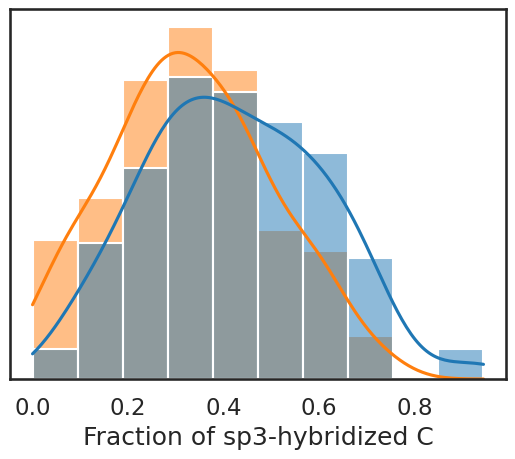

In [172]:
plt.ylabel('')
plt.yticks([])

plot = sns.histplot(data=df_concat, 
             x='frac_sp3', 
             hue='source', 
             kde=True, 
             stat='density', 
             common_norm=False,
             bins=10,
             #kde_kws={'bw_adjust': 1.5},
             legend=False
             )

#plt.xlabel('Molecular weight (g/mol)')
plt.xlabel('Fraction of sp3-hybridized C')

#plot.get_legend().set_title("")
#plt.savefig('dokcking_frac_sp3.pdf', bbox_inches='tight')

In [166]:
chembl_scores = pd.read_csv('docking/gnina_out_chembl/scores.csv')
chembl_scores['source'] = 'ChEMBL32'
profis_scores = pd.read_csv('docking/gnina_out_profis/scores.csv')
profis_scores['source'] = 'PROFIS'

In [170]:
scores = pd.concat([profis_scores, chembl_scores], ignore_index=True)


/home/bmc/miniconda3/envs/profis/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/bmc/miniconda3/envs/profis/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/bmc/miniconda3/envs/profis/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/bmc/miniconda3/envs/profis/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future versi

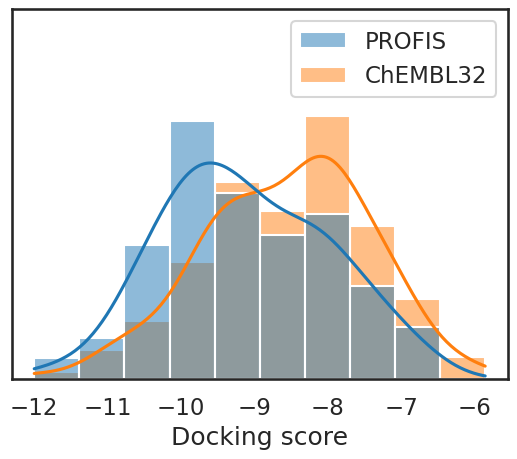

In [198]:
plot = sns.histplot(scores, x='score', hue='source', kde=True, stat='density', common_norm=False, bins=10,)
plt.ylabel('')
plt.yticks([])
plt.ylim([0, 0.55])
plot.get_legend().set_title("")
plt.xlabel('Docking score')
plt.savefig('dokcking_scores.pdf', bbox_inches='tight')

In [200]:
profis_scores

,smiles,score,time,source
0,COc1ccc(C=Cc2cc(S(N)(=O)=O)c(O)cc2O)cc1C 181,-9.61,4.368,PROFIS
1,CCCCN1CCCCCC1CN(S(=O)(=O)c1cc(F)ccc1F)CC2CC2 1041,-7.53,7.738,PROFIS
2,Cc1ccc(S(=O)(=O)CCCC(=O)NC(=O)Nc2c(F)cccc2F)cc...,-10.27,6.097,PROFIS
3,O=C1CCC(=N)N1CCCCN1CCN(c2c(F)cccc2F)CC1CCCC 1660,-8.70,8.038,PROFIS
4,COc1ccc(S(=O)(=O)N(C)C)cc1OCC(=O)OCC(=O)NC1CCC...,-8.05,9.854,PROFIS
...,...,...,...,...
101,CN(CCc1ccco1)C(=O)N1CCC2C(=O)N(c3cccc4ccccc34)...,-10.58,4.936,PROFIS
102,CCC1CNN(S(=O)(=O)N2CCCC(C(=O)Nc3ccc4ccc(C)ccc4...,-10.66,6.977,PROFIS
103,CC(Cc1ccccc1)NC(=O)c1cccc(-c2nnc(CCCCC)o2)c1 8810,-10.04,7.226,PROFIS
104,CCc1ccccc1C(=O)N1CCC(CO)C1C(=O)OCCCCC 9440,-8.13,6.689,PROFIS


In [204]:
from scipy.stats import kstest

kstest(chembl_scores['score'],profis_scores['score'],alternative='less')

KstestResult(statistic=0.2359748427672956, pvalue=0.0007804263488707005, statistic_location=-8.86, statistic_sign=-1)

In [208]:
df = pd.read_parquet('data/d2_ECFP_100nM.parquet').sample(150)
df.head()

,activity,Ki,fps,smiles
5988,0,197.0,"[14, 95, 165, 207, 216, 249, 319, 352, 356, 37...",COc1cccc(OC)c1C(=O)NN1c2ccccc2N=C(N2CCN(C)CC2)...
8508,0,1862.0,"[119, 135, 328, 352, 378, 562, 728, 766, 806, ...",Cn1cncc1-c1c[nH]c2ccc(Br)cc12
7971,1,17.0,"[80, 114, 119, 155, 293, 294, 555, 580, 736, 7...",CCN(C)CCc1c(-c2cccc(C(F)(F)F)c2)[nH]c2ccccc12
9079,0,1923.0,"[57, 74, 80, 319, 350, 389, 407, 496, 575, 650...",CS(=O)(=O)c1cccc(N2CCN(Cc3ccccc3)CC2)c1
4121,0,3700.0,"[9, 80, 83, 114, 220, 305, 310, 314, 322, 326,...",COc1ccc2c3c(c(=O)oc2c1)CN(Cc1ccc(C(F)(F)F)cc1)CC3


In [209]:
df = pd.DataFrame(df.smiles)
df.to_csv('docking/d2_set.smi', sep='\t')

In [210]:
df.head()

,smiles
5988,COc1cccc(OC)c1C(=O)NN1c2ccccc2N=C(N2CCN(C)CC2)...
8508,Cn1cncc1-c1c[nH]c2ccc(Br)cc12
7971,CCN(C)CCc1c(-c2cccc(C(F)(F)F)c2)[nH]c2ccccc12
9079,CS(=O)(=O)c1cccc(N2CCN(Cc3ccccc3)CC2)c1
4121,COc1ccc2c3c(c(=O)oc2c1)CN(Cc1ccc(C(F)(F)F)cc1)CC3
